## Natural Gas Burn By Site Exploratory Data Analysis

Notebook is intended to gain a better understanding of the data for daily and hourly gas burn at the Natural Gas Sites

In [214]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
import pydata_google_auth
from pathlib import Path

In [2]:
notebook_dir = Path(os.getcwd())
parent_dir = str(notebook_dir.parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [150]:
from scripts.gather_historic_data import gather_historic_data
from scripts.data_pull_functions import run_natural_gas_burn_query, pull_unit_availability, run_generation_query
from scripts.data_clean_functions import clean_generation_unit_data
from scripts.queries import GAS_BURN_QUERY, PGS_GENERATION_QUERY, NON_PGS_GENERATION_QUERY
from scripts.constants import SITE_BURN_DATATYPES, AVAILABILITY_FILES_CSV, AVAILABILITY_FILES_XLSX, SITE_GENERATION_DATATYPES, SITE_GENERATION_LIMITS

In [5]:
# Google Cloud Credentials
credentials = pydata_google_auth.get_user_credentials(
    scopes=["https://www.googleapis.com/auth/cloud-platform"],
    auth_local_webserver=True,
)

client = bigquery.Client(project="bepc-prj-energy-prod", credentials=credentials )

In [180]:
ng_data = pd.read_csv('../data/processed-data/historic_data_df.csv')
ng_data['datetime'] = pd.to_datetime(ng_data['datetime'])
print(ng_data.shape)
ng_data.head()

(184878, 28)


,datetime,site,year,month,day,hour,hour_end,day_of_week,gas_day,hourly_gas_burn_MMBtu,...,wind_speed_forecast,total_offline_forecast,offline_ng_forecast,offline_coal_forecast,load_actual,net_load_actual,wind_actual,temperature_actual,wind_speed_actual,total_outages
0,2023-12-01 01:00:00,PGS,2023,12,1,1,HE2,4,2023-11-30,2319.289701,...,2.80,14626.7,7794.0,6832.7,27907.0,11886.62,15672.910,14.000000,3.45,14626.7
1,2023-12-01 02:00:00,PGS,2023,12,1,2,HE3,4,2023-11-30,1961.642224,...,2.80,14626.7,7794.0,6832.7,27835.0,12345.12,15262.724,9.333333,4.55,14626.7
2,2023-12-01 03:00:00,PGS,2023,12,1,3,HE4,4,2023-11-30,2284.608734,...,2.15,14389.1,7691.4,6697.7,27970.0,13126.33,14808.898,14.000000,2.85,14389.1
3,2023-12-01 04:00:00,PGS,2023,12,1,4,HE5,4,2023-11-30,1961.642224,...,4.65,14389.1,7691.4,6697.7,28471.0,14576.82,14124.747,15.333333,4.00,14389.1
4,2023-12-01 05:00:00,PGS,2023,12,1,5,HE6,4,2023-11-30,2163.225347,...,4.35,14389.1,7691.4,6697.7,29643.0,16708.62,13585.278,13.333333,5.15,14389.1


## Overall Summary

In [181]:
print(f'shape of the dataframe: {ng_data.shape}')

shape of the dataframe: (184878, 28)


Null values appear in some of the columns. Columns of concern are:
- Availability MW (30%) => suspected that this is b/c the files only go back to 2024 where as the data I'm pulling goes back to 2023
- Hourly Gas Burn MMBtu => I suspect this is because there are days where the station isn't running

In [182]:
ng_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 184878 entries, 0 to 184877
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   datetime                184878 non-null  datetime64[us]
 1   site                    184878 non-null  str           
 2   year                    184878 non-null  int64         
 3   month                   184878 non-null  int64         
 4   day                     184878 non-null  int64         
 5   hour                    184878 non-null  int64         
 6   hour_end                184878 non-null  str           
 7   day_of_week             184878 non-null  int64         
 8   gas_day                 184878 non-null  str           
 9   hourly_gas_burn_MMBtu   150366 non-null  float64       
 10  daily_gas_burn_MMBtu    184878 non-null  float64       
 11  hourly_site_gen_mw      184878 non-null  float64       
 12  daily_site_gen_mw       184878 non-null  

In [183]:
print(f'percent null per column:\n{ng_data.isnull().sum()}')

percent null per column:
datetime                      0
site                          0
year                          0
month                         0
day                           0
hour                          0
hour_end                      0
day_of_week                   0
gas_day                       0
hourly_gas_burn_MMBtu     34512
daily_gas_burn_MMBtu          0
hourly_site_gen_mw            0
daily_site_gen_mw             0
availability_mw           93903
load_forecast                28
net_load_forecast            28
wind_forecast                28
temperature_forecast         28
wind_speed_forecast          28
total_offline_forecast       87
offline_ng_forecast          87
offline_coal_forecast        87
load_actual                  28
net_load_actual              28
wind_actual                 203
temperature_actual          519
wind_speed_actual           126
total_outages                87
dtype: int64


In [184]:
print(f'percent null per column:\n{ng_data.isnull().sum()/ng_data.shape[0]}')

percent null per column:
datetime                  0.000000
site                      0.000000
year                      0.000000
month                     0.000000
day                       0.000000
hour                      0.000000
hour_end                  0.000000
day_of_week               0.000000
gas_day                   0.000000
hourly_gas_burn_MMBtu     0.186674
daily_gas_burn_MMBtu      0.000000
hourly_site_gen_mw        0.000000
daily_site_gen_mw         0.000000
availability_mw           0.507919
load_forecast             0.000151
net_load_forecast         0.000151
wind_forecast             0.000151
temperature_forecast      0.000151
wind_speed_forecast       0.000151
total_offline_forecast    0.000471
offline_ng_forecast       0.000471
offline_coal_forecast     0.000471
load_actual               0.000151
net_load_actual           0.000151
wind_actual               0.001098
temperature_actual        0.002807
wind_speed_actual         0.000682
total_outages             0.00

In [185]:
# For the availability data it looks like we might be missing data for April 2024 and earlier and 2025 October and December. It seems like these files aren't always pulled the same way every month. Some months contain the month that is specified on the file name other months contain the data for the month before the month specified on the file name
ng_data[ng_data['availability_mw'].isnull()].groupby(by=['year', 'month']).count()

datetime  site   day  hour  hour_end  day_of_week  gas_day  \
year month                                                               
2022 1          2972  2972  2972  2972      2972         2972     2972   
     2          2688  2688  2688  2688      2688         2688     2688   
     3          2976  2976  2976  2976      2976         2976     2976   
     4          2880  2880  2880  2880      2880         2880     2880   
     5          2976  2976  2976  2976      2976         2976     2976   
     6          2880  2880  2880  2880      2880         2880     2880   
     7          2976  2976  2976  2976      2976         2976     2976   
     8          2976  2976  2976  2976      2976         2976     2976   
     9          2880  2880  2880  2880      2880         2880     2880   
     10         2976  2976  2976  2976      2976         2976     2976   
     11         2892  2892  2892  2892      2892         2892     2892   
     12         2976  2976  2976  2976      2976         2976     2976   
2023 1          2976  2976  2976  2976      2976         2976     2976   
     2          2688  2688  2688  2688      2688         2688     2688   
     3          2976  2976  2976  2976      2976         2976     2976   
     4          2880  2880  2880  2880      2880         2880     2880   
     5          2976  2976  2976  2976      2976         2976     2976   
     6          2880  2880  2880  2880      2880         2880     2880   
     7          2976  2976  2976  2976      2976         2976     2976   
     8          2976  2976  2976  2976      2976         2976     2976   
     9          2880  2880  2880  2880      2880         2880     2880   
     10         2976  2976  2976  2976      2976         2976     2976   
     11         2892  2892  2892  2892      2892         2892     2892   
     12         3719  3719  3719  3719      3719         3719     3719   
2024 1          3720  3720  3720  3720      3720         3720     3720   
     2          3480  3480  3480  3480      3480         3480     3480   
     3          3720  3720  3720  3720      3720         3720     3720   
     4          3600  3600  3600  3600      3600         3600     3600   
     5           120   120   120   120       120          120      120   
     7           120   120   120   120       120          120      120   
     8           120   120   120   120       120          120      120   
     10          120   120   120   120       120          120      120   
     11            5     5     5     5         5            5        5   
     12            5     5     5     5         5            5        5   
2025 1             5     5     5     5         5            5        5   
     10         3600  3600  3600  3600      3600         3600     3600   
     12         3600  3600  3600  3600      3600         3600     3600   
2026 8           845   845   845   845       845          845      845   

            hourly_gas_burn_MMBtu  daily_gas_burn_MMBtu  hourly_site_gen_mw  \
year month                                                                    
2022 1                       2662                  2972                2972   
     2                       2356                  2688                2688   
     3                       2472                  2976                2976   
     4                       2314                  2880                2880   
     5                       2222                  2976                2976   
     6                       2616                  2880                2880   
     7                       2904                  2976                2976   
     8                       2578                  2976                2976   
     9                       2074                  2880                2880   
     10                      1612                  2976                2976   
     11                      2072                  2892                2892   
     12                 

In [186]:
# for hourly gas burn, there are more months with missing values but there doesn't appear to be pattern behind it. These could be legitimate 0s
ng_data[ng_data['hourly_gas_burn_MMBtu'].isnull()].groupby(by=['year', 'month']).count()

datetime  site   day  hour  hour_end  day_of_week  gas_day  \
year month                                                               
2022 1           310   310   310   310       310          310      310   
     2           332   332   332   332       332          332      332   
     3           504   504   504   504       504          504      504   
     4           566   566   566   566       566          566      566   
     5           754   754   754   754       754          754      754   
     6           264   264   264   264       264          264      264   
     7            72    72    72    72        72           72       72   
     8           398   398   398   398       398          398      398   
     9           806   806   806   806       806          806      806   
     10         1364  1364  1364  1364      1364         1364     1364   
     11          820   820   820   820       820          820      820   
     12          692   692   692   692       692          692      692   
2023 1           264   264   264   264       264          264      264   
     2           278   278   278   278       278          278      278   
     3           490   490   490   490       490          490      490   
     4           336   336   336   336       336          336      336   
     5           940   940   940   940       940          940      940   
     6           836   836   836   836       836          836      836   
     7           110   110   110   110       110          110      110   
     8           106   106   106   106       106          106      106   
     9           542   542   542   542       542          542      542   
     10          480   480   480   480       480          480      480   
     11          476   476   476   476       476          476      476   
     12          428   428   428   428       428          428      428   
2024 1           240   240   240   240       240          240      240   
     2           292   292   292   292       292          292      292   
     3           936   936   936   936       936          936      936   
     4           514   514   514   514       514          514      514   
     5          1094  1094  1094  1094      1094         1094     1094   
     6          1186  1186  1186  1186      1186         1186     1186   
     7           538   538   538   538       538          538      538   
     8            48    48    48    48        48           48       48   
     9           892   892   892   892       892          892      892   
     10         1186  1186  1186  1186      1186         1186     1186   
     11          857   857   857   857       857          857      857   
     12          500   500   500   500       500          500      500   
2025 1           566   566   566   566       566          566      566   
     2           384   384   384   384       384          384      384   
     3          1526  1526  1526  1526      1526         1526     1526   
     4          1330  1330  1330  1330      1330         1330     1330   
     5           840   840   840   840       840          840      840   
     6           490   490   490   490       490          490      490   
     7            38    38    38    38        38           38       38   
     8           370   370   370   370       370          370      370   
     9           124   124   124   124       124          124      124   
     10         1560  1560  1560  1560      1560         1560     1560   
     11          664   664   664   664       664          664      664   
     12          706   706   706   706       706          706      706   
2026 1           350   350   350   350       350          350      350   
     2           202   202   202   202       202          202      202   
     3           412   412   412   412       412          412      412   
     4          1186  1186  1186  1186      1186         1186     1186   
     5          

In [187]:
ng_data.describe()

,datetime,year,month,day,hour,day_of_week,hourly_gas_burn_MMBtu,daily_gas_burn_MMBtu,hourly_site_gen_mw,daily_site_gen_mw,...,wind_speed_forecast,total_offline_forecast,offline_ng_forecast,offline_coal_forecast,load_actual,net_load_actual,wind_actual,temperature_actual,wind_speed_actual,total_outages
count,184878,184878.000000,184878.000000,184878.000000,184878.000000,184878.000000,150366.000000,184878.000000,1.848780e+05,1.848780e+05,...,184850.000000,184791.000000,184791.000000,184791.000000,184850.000000,184850.000000,184675.000000,184359.000000,184752.000000,184791.000000
mean,2024-06-03 13:05:27.368318,2023.948582,6.208256,15.665477,11.496933,3.001011,1196.681191,23408.635654,5.769567e+02,1.384602e+04,...,10.083123,13424.186513,8565.183177,4859.003336,33168.939324,18799.638182,12641.620353,39.547005,10.067836,13424.186513
min,2022-01-01 01:00:00,2022.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,...,0.000000,1635.460000,970.760000,100.000000,22431.000000,-4755.840000,167.107000,-47.666667,0.000000,1635.460000
25%,2023-04-27 08:15:00,2023.000000,3.000000,8.000000,5.000000,1.000000,226.632657,3846.000000,0.000000e+00,2.906000e+02,...,6.500000,7784.700000,5064.880000,2636.450000,29189.000000,11837.090000,8077.729000,17.666667,6.300000,7784.700000
50%,2024-06-28 23:00:00,2024.000000,6.000000,16.000000,11.000000,3.000000,783.019754,14421.000000,5.390000e+01,1.379000e+03,...,9.000000,12134.100000,7851.160000,4368.400000,31770.000000,18555.428334,13117.530000,41.333333,9.200000,12134.100000
75%,2025-07-18 23:45:00,2025.000000,9.000000,23.000000,17.000000,5.000000,1612.691851,32465.000000,1.460000e+02,3.258300e+03,...,12.750000,19038.600000,11746.965000,6779.900000,35832.000000,25088.722500,17295.194000,65.000000,13.250000,19038.600000
max,2026-08-08 00:00:00,2026.000000,12.000000,31.000000,23.000000,6.000000,22217.014695,372480.000000,9.993521e+06,1.000019e+07,...,35.150000,29890.800000,19281.140000,12523.800000,59416.000000,49436.439167,26115.043000,107.666667,61.550000,29890.800000
std,NaN,1.324752,3.406565,8.813794,6.923520,2.000277,1668.785025,34115.540621,6.959861e+04,3.414089e+05,...,4.889782,6450.280986,4172.760941,2701.356779,5826.541326,9584.800235,5460.225942,29.913930,5.402473,6450.280986


### Summary of Gas Burn by Site

In [188]:
ng_burn_data = run_natural_gas_burn_query(client, [GAS_BURN_QUERY], '2023-01-01', '2026-08-01')
ng_burn_data['daily_gas_burn_MMBtu'] = ng_burn_data['daily_gas_burn_MMBtu'].astype('float')
ng_burn_data.to_csv('../data/raw-data/run_natural_gas_burn_query.csv', index=False)
#ng_burn_data.head()

In [189]:
ng_burn_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6545 entries, 0 to 6544
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   gas_day               6545 non-null   datetime64[us]
 1   site                  6545 non-null   str           
 2   daily_gas_burn_MMBtu  6545 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 172.7 KB


In [190]:
print(ng_burn_data['gas_day'].min())
print(ng_burn_data['gas_day'].max())

2023-01-01 00:00:00
2026-08-01 00:00:00


In [191]:
# Note that all locations, except LCS, have 0's in the daily burn. 
(ng_burn_data
 .groupby(by = ['site'])
 .agg(
    count=('daily_gas_burn_MMBtu', 'count'),
    min=('daily_gas_burn_MMBtu', 'min'),
    median=('daily_gas_burn_MMBtu', 'median'),
    max=('daily_gas_burn_MMBtu', 'max'),
    mean=('daily_gas_burn_MMBtu', 'mean'),
    std=('daily_gas_burn_MMBtu', 'std'),
    var=('daily_gas_burn_MMBtu', 'var')
 )
 .round(2)
)

,count,min,median,max,mean,std,var
site,,,,,,,
CGS,1309,0.0,7385.0,39944.0,8405.73,9067.00,8.221041e+07
DCS,1309,0.0,29113.0,105556.0,28939.86,23900.47,5.712325e+08
GGS,1309,0.0,5563.0,49218.0,6720.24,7374.06,5.437671e+07
LCS,1309,11.0,29525.0,108892.0,30452.48,14794.34,2.188724e+08
PGS,1309,0.0,33840.0,372480.0,55728.15,61717.25,3.809019e+09


In [192]:
# how many zeros are there?
ng_burn_data[ng_burn_data['daily_gas_burn_MMBtu']==0].groupby('site').count()

,gas_day,daily_gas_burn_MMBtu
site,,
CGS,483,483
DCS,203,203
GGS,322,322
PGS,11,11


It looks like there may be some outliers when viewing the aggregated data. The bulk of the data is between 0 and 50,000 MMBtus, but there are some others that are greater than 100,000. Are these real observations. However, when looking at it by site, the bulk of the large values are all at PGS

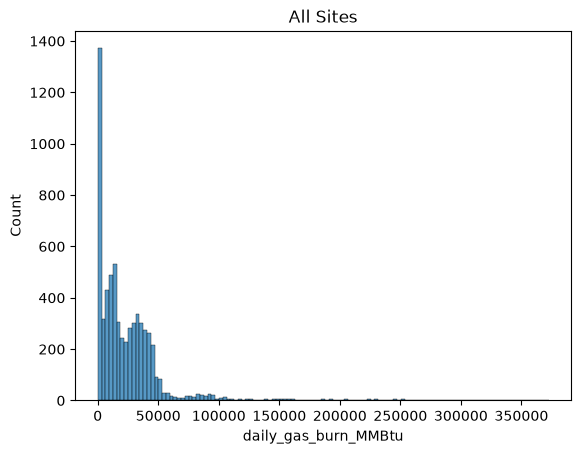

In [193]:
ax = sns.histplot(data=ng_burn_data, x='daily_gas_burn_MMBtu', )
ax.set_title('All Sites')
plt.show()

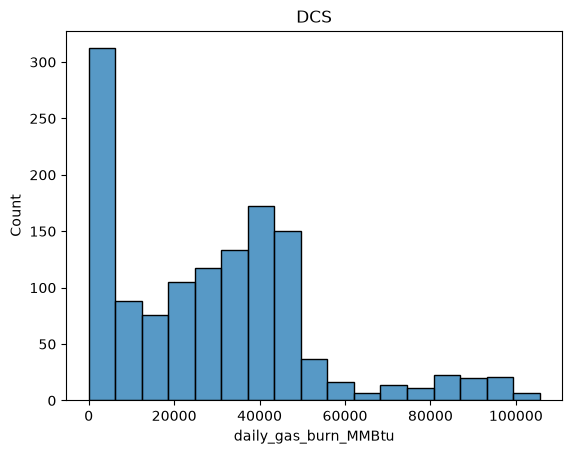

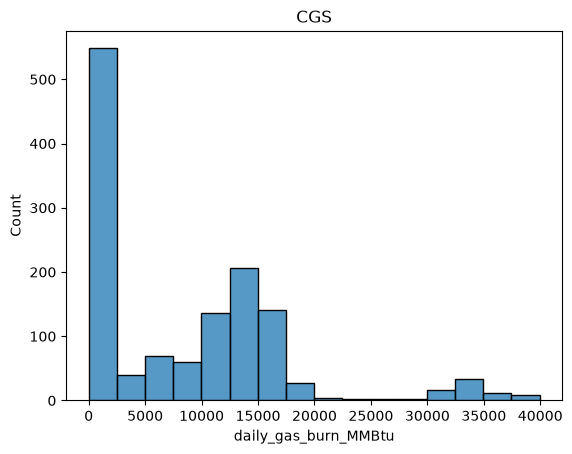

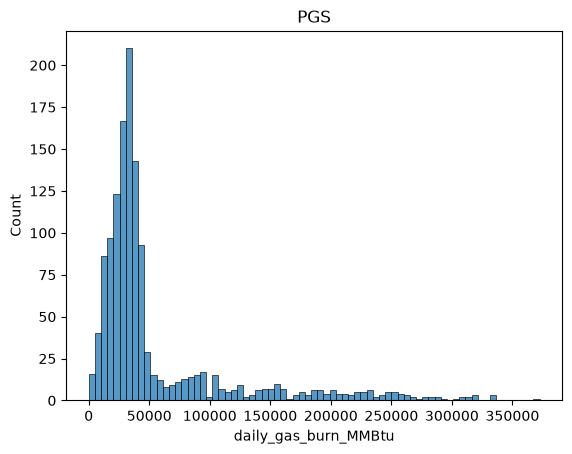

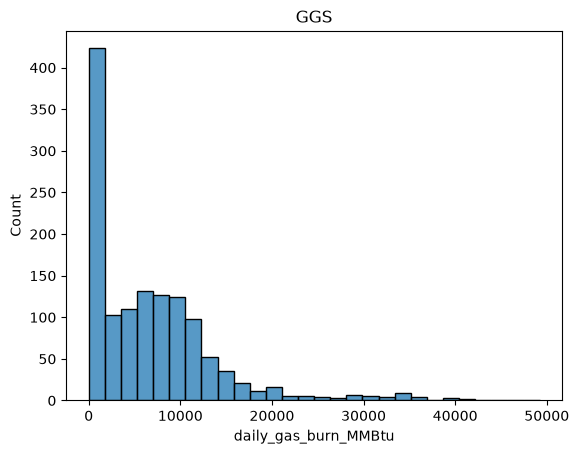

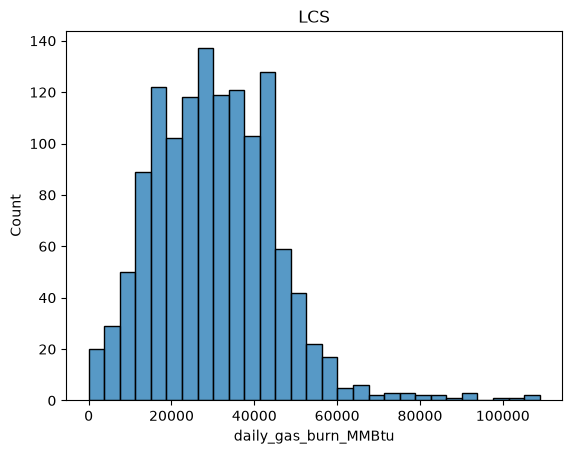

In [194]:
# there is definately still some zero inflation going on. CGS, DCS, and GGS visually have the most issue with 0s. CGS and GGS are peaking stations, maybe zeros can make sense if the zeros correspond to low demand days
for site in ng_burn_data['site'].unique():
    ax = sns.histplot(data=ng_burn_data[ng_burn_data['site']==site], x='daily_gas_burn_MMBtu', )
    ax.set_title(site)
    plt.show()

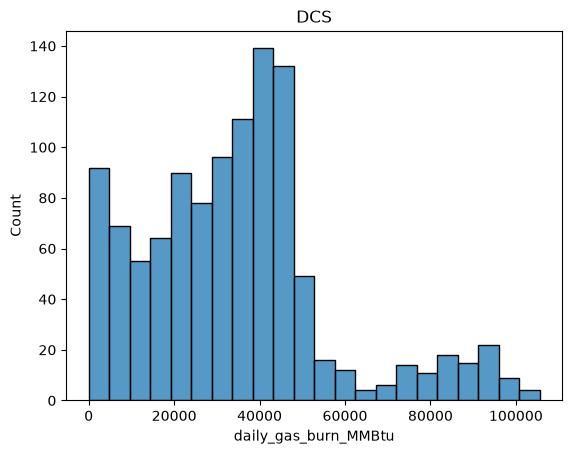

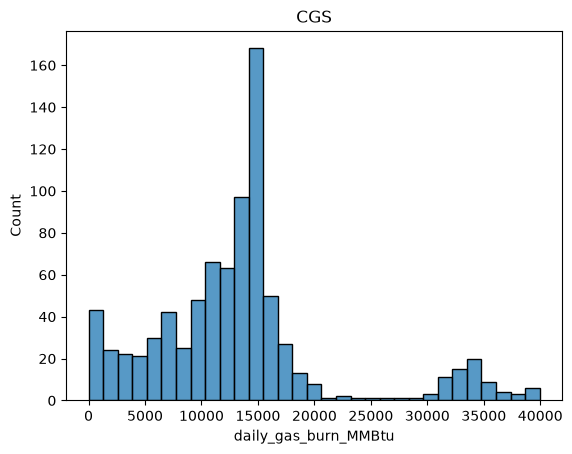

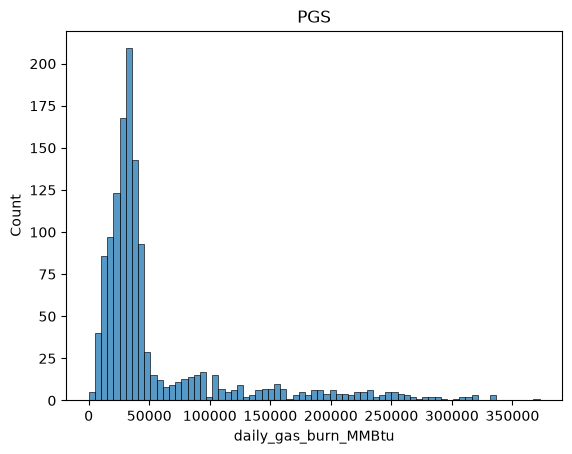

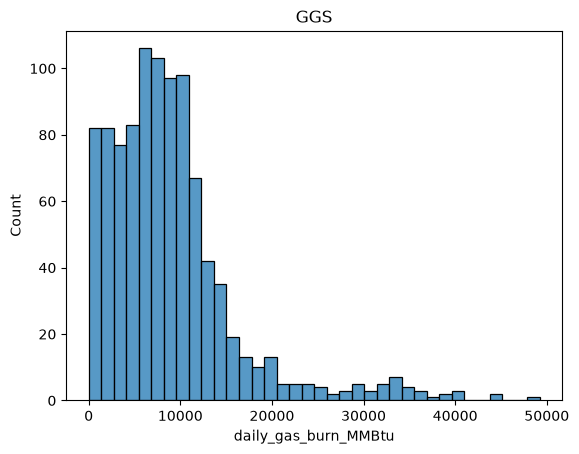

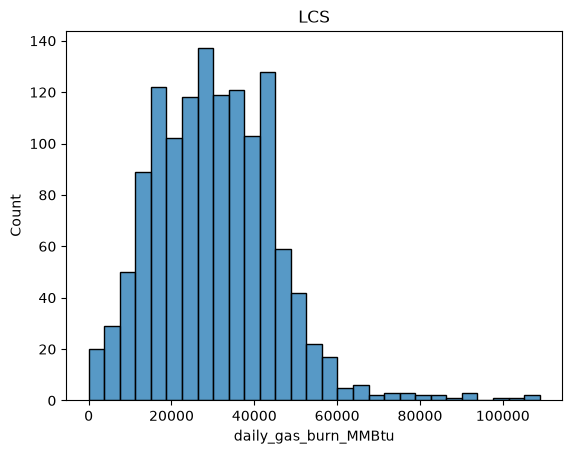

In [195]:
#removing the zeros, 
for site in ng_burn_data['site'].unique():
    ax = sns.histplot(data=ng_burn_data[(ng_burn_data['site']==site) & (ng_burn_data['daily_gas_burn_MMBtu']!=0)], x='daily_gas_burn_MMBtu', )
    ax.set_title(site)
    plt.show()

In [196]:
# are the zeros tied to availability
availability = pull_unit_availability(excel_files=AVAILABILITY_FILES_XLSX, csv_files=AVAILABILITY_FILES_CSV, sheet='Gas HEL Transposed', start_date='2024-01-01', end_date='2026-08-01')['site_availability_df']
availability['gas_day'] = (pd.to_datetime(availability["datetime"]) - pd.Timedelta(hours=10)).dt.date
availability['gas_day'] = pd.to_datetime(availability['gas_day'])

In [197]:
availability = availability.groupby(['site', 'gas_day'])['availability_mw'].agg('sum').reset_index()

In [198]:
burn_and_availability = ng_burn_data.merge(availability, on=['site', 'gas_day'], how='left')

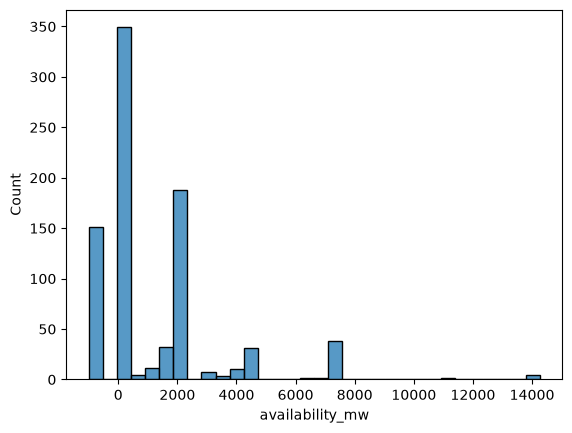

In [199]:
# This shows that the bulk of the days with zero burn are when the units are unavailable
zero_burn_days_availability = burn_and_availability[(burn_and_availability['daily_gas_burn_MMBtu']==0) & (burn_and_availability['gas_day']>='2024-01-01')].loc[:, ['site', 'availability_mw']].fillna(-999)
sns.histplot(data=pd.DataFrame(zero_burn_days_availability), x='availability_mw')
plt.show()

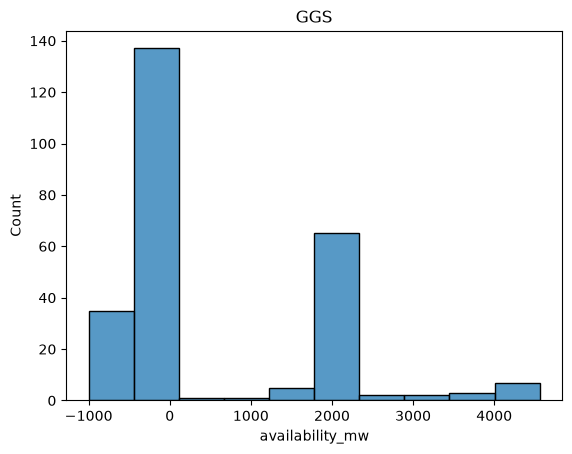

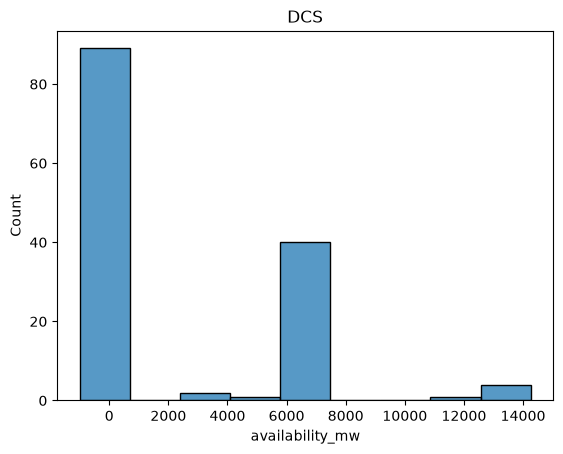

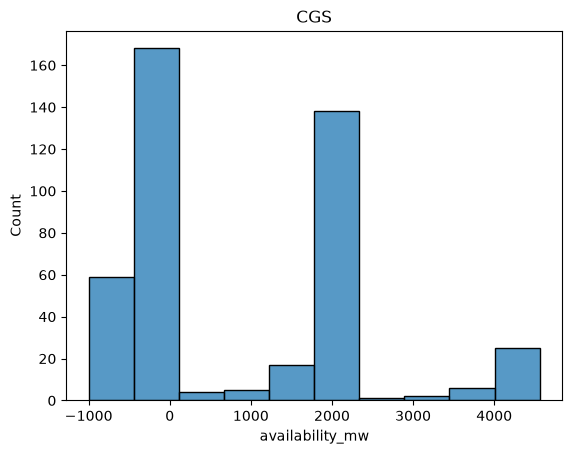

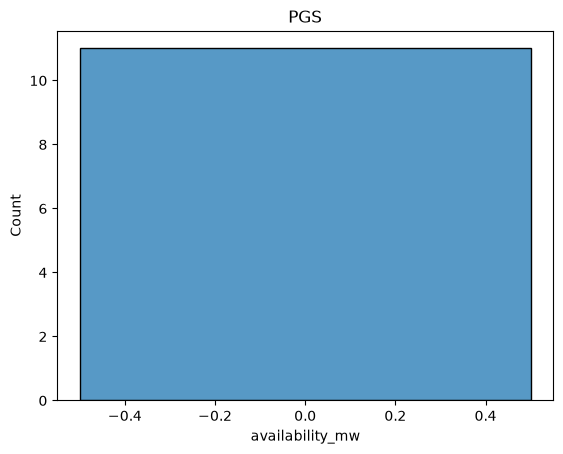

In [200]:
# Notice that PGS only has zero burn days when availability is also zero. The others are roughly centered around a single common number
for site in zero_burn_days_availability['site'].unique():
    ax = sns.histplot(data=zero_burn_days_availability[zero_burn_days_availability['site']==site], x='availability_mw', )
    ax.set_title(site)
    plt.show()

In [201]:
# scrolling through the years
# 2024 only missing April and earlier
# 2025 Appear to be from October and December which I pointed out as being an issue earlier
# 2026 Only on August so far
burn_and_availability[(burn_and_availability['availability_mw'].isna()) & (burn_and_availability['gas_day'].dt.year == 2026)].sort_values(by=['gas_day'])

,gas_day,site,daily_gas_burn_MMBtu,availability_mw
6540,2026-08-01,DCS,62602.0,NaN
6541,2026-08-01,LCS,46396.0,NaN
6542,2026-08-01,PGS,220878.0,NaN
6543,2026-08-01,CGS,0.0,NaN
6544,2026-08-01,GGS,29436.0,NaN


### Generation EDA

In [202]:
generation_df = run_generation_query(client, [PGS_GENERATION_QUERY, NON_PGS_GENERATION_QUERY], '2024-01-01', '2026-08-01', SITE_GENERATION_DATATYPES)
site_generation_df = clean_generation_unit_data(generation_df)['hourly_site_generation_df']
site_generation_df.to_csv('../data/raw-data/site_generation.csv', index=False)

In [203]:
site_generation_df.info()

<class 'pandas.DataFrame'>
Index: 113280 entries, 4 to 113275
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   datetime            113280 non-null  datetime64[ns]
 1   gas_day             113280 non-null  datetime64[s] 
 2   hour                113280 non-null  str           
 3   site                113280 non-null  str           
 4   hourly_site_gen_mw  113280 non-null  float64       
dtypes: datetime64[ns](1), datetime64[s](1), float64(1), str(2)
memory usage: 6.0 MB


In [204]:
(site_generation_df
.groupby(by='site')
.agg(
    count=('hourly_site_gen_mw', 'count'),
    min=('hourly_site_gen_mw', 'min'),
    median=('hourly_site_gen_mw', 'median'),
    max=('hourly_site_gen_mw', 'max'),
    mean=('hourly_site_gen_mw', 'mean'),
    std=('hourly_site_gen_mw', 'std'),
    var=('hourly_site_gen_mw', 'var')
 )
 .round(2)
    
)

,count,min,median,max,mean,std,var
site,,,,,,,
CGS,22656,0.0,0.0,2866.70,27.36,37.91,1436.96
DCS,22656,0.0,161.0,298.00,135.72,117.91,13903.01
GGS,22656,0.0,0.0,8971.00,23.88,71.93,5173.58
LCS,22656,0.0,107.4,481892.79,127.75,3201.52,10249709.11
PGS,22656,0.0,161.6,762.30,209.12,171.53,29421.33


In [205]:
# There appears to be a large number of 0's especially for CGS and GGS which have a median value of 0, although all sites have 0s
# For reference there are 22,656 total records for each site
# I believe CGS is on a long term outage - the most recent date with generation is from March 2026
# GGS appears to have had a long outage in 2024 (May 1st to July 21st) and again from Aug 17th to Oct 18th ish
site_generation_df[site_generation_df['hourly_site_gen_mw']==0].groupby(by='site').count()

,datetime,gas_day,hour,hourly_site_gen_mw
site,,,,
CGS,12760,12760,12760,12760
DCS,8301,8301,8301,8301
GGS,14488,14488,14488,14488
LCS,1691,1691,1691,1691
PGS,683,683,683,683


In [206]:
SITE_GENERATION_LIMITS

{'CGS': 95, 'DCS': 297, 'LCS': 270, 'PGS': 803.4, 'GGS': 190}

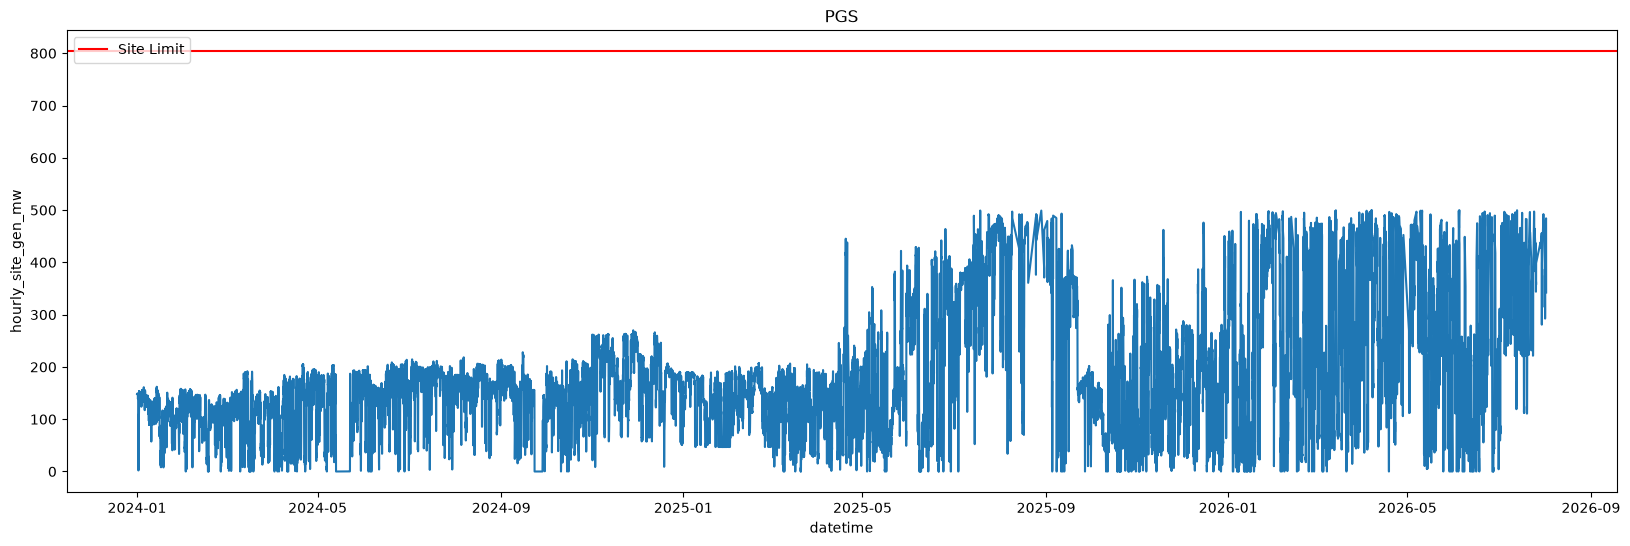

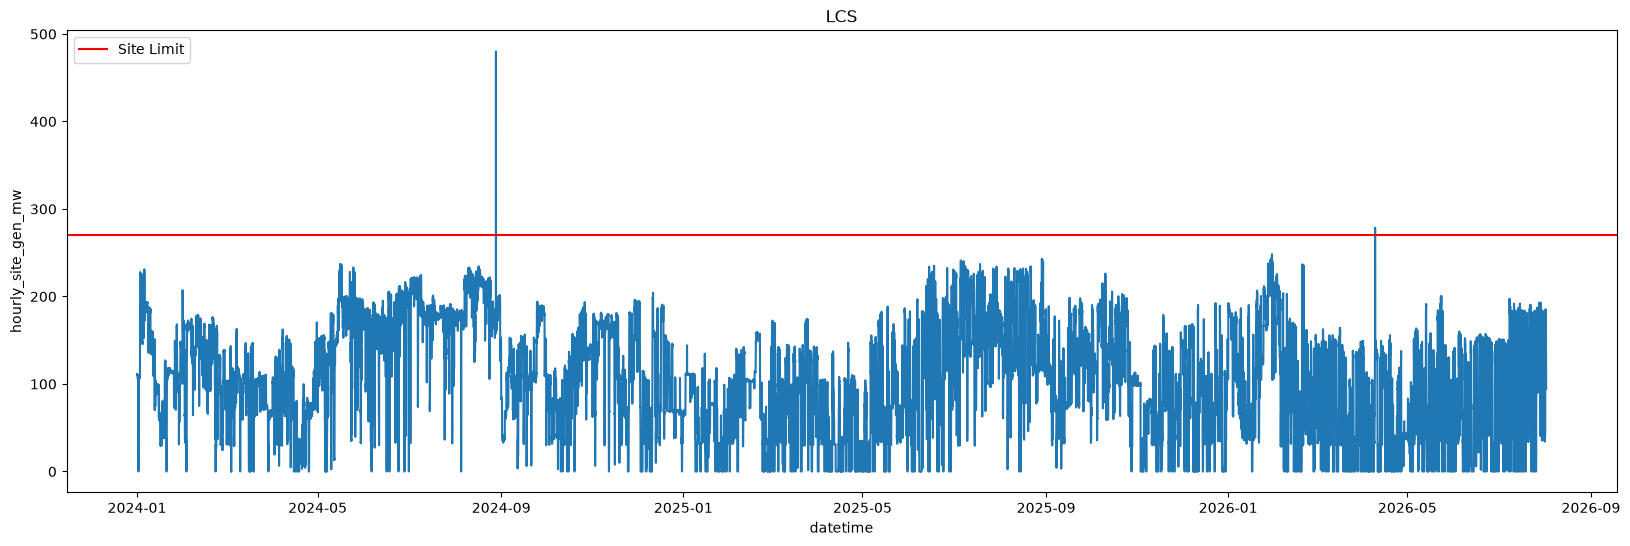

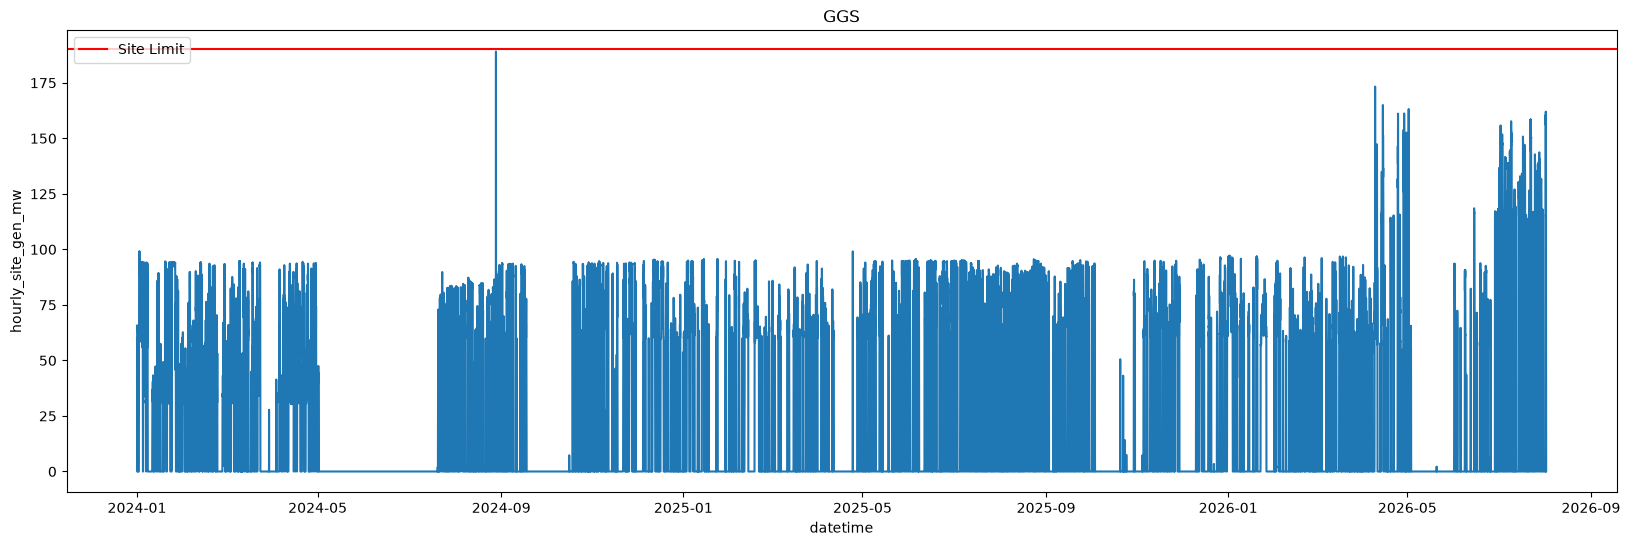

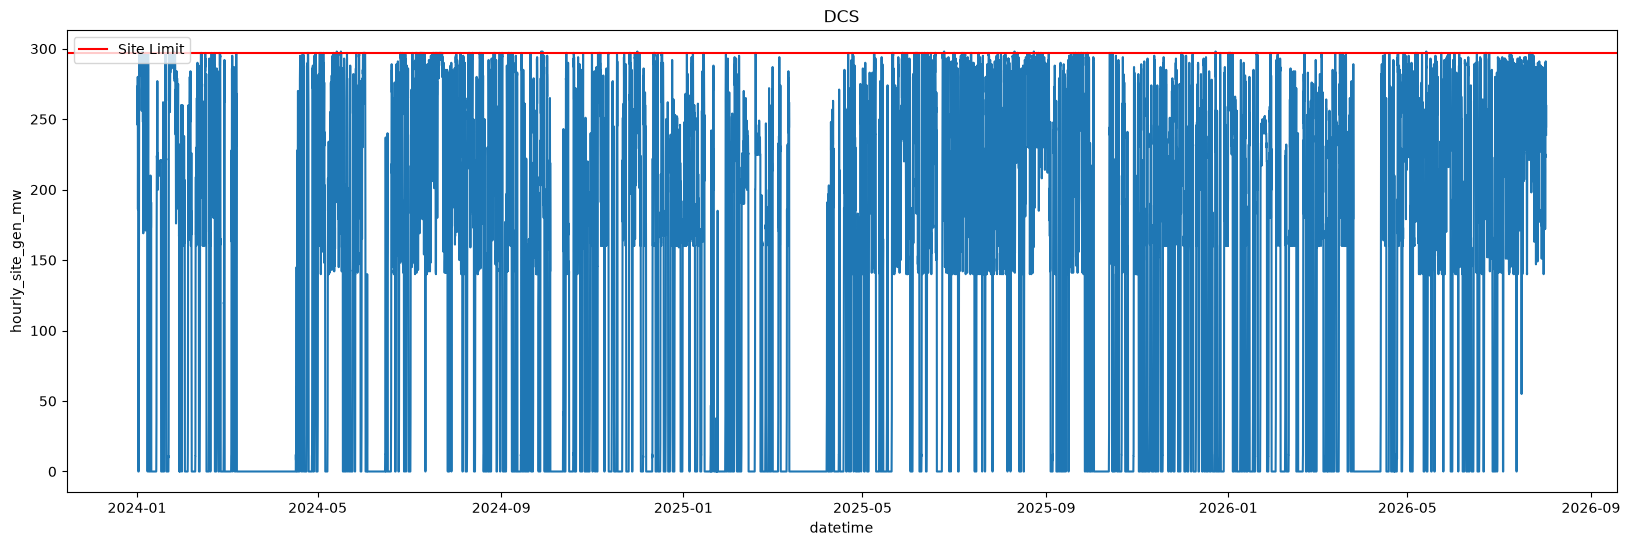

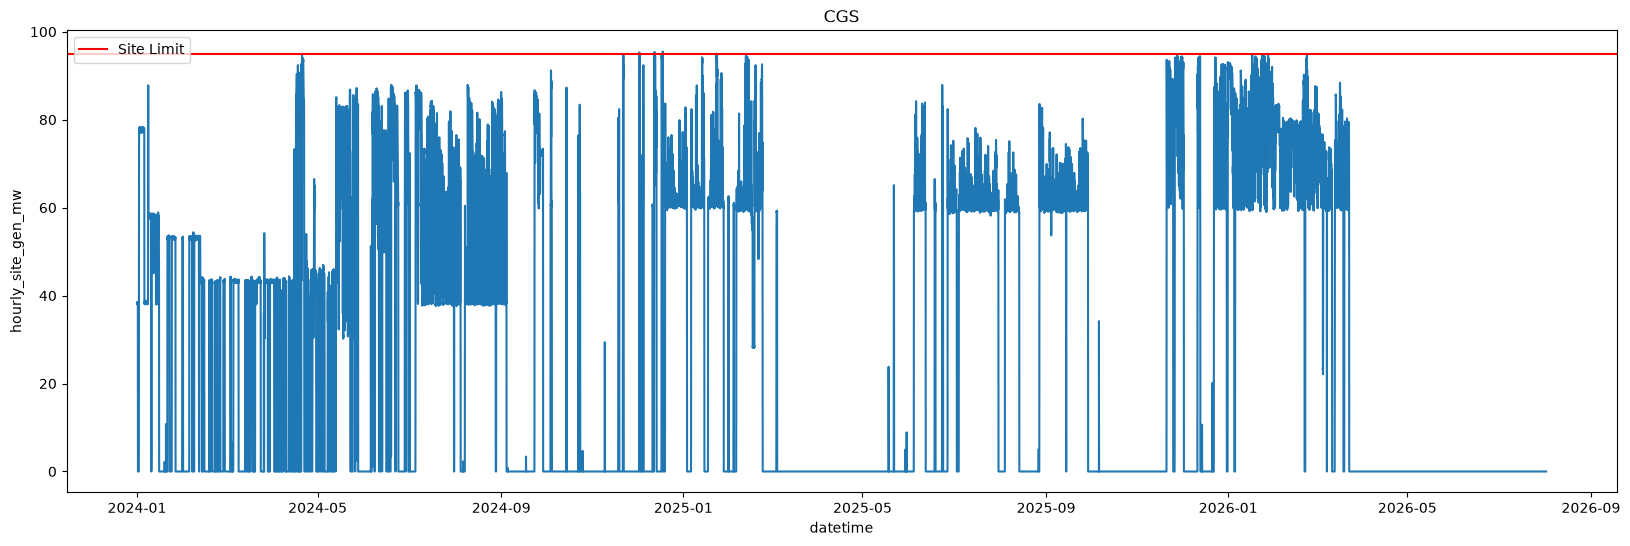

In [207]:
for site in site_generation_df['site'].unique():
    plt.figure(figsize=(20, 6))
    ax = sns.lineplot(data = site_generation_df[(site_generation_df['hourly_site_gen_mw']<500) & (site_generation_df['site']==site)], x='datetime', y='hourly_site_gen_mw')
    ax.set_title(site)
    ax.axhline(y=SITE_GENERATION_LIMITS[site], color='red', label='Site Limit')
    plt.legend(loc='upper left')
    plt.show()

In [208]:
ng_data.columns

Index(['datetime', 'site', 'year', 'month', 'day', 'hour', 'hour_end',
       'day_of_week', 'gas_day', 'hourly_gas_burn_MMBtu',
       'daily_gas_burn_MMBtu', 'hourly_site_gen_mw', 'daily_site_gen_mw',
       'availability_mw', 'load_forecast', 'net_load_forecast',
       'wind_forecast', 'temperature_forecast', 'wind_speed_forecast',
       'total_offline_forecast', 'offline_ng_forecast',
       'offline_coal_forecast', 'load_actual', 'net_load_actual',
       'wind_actual', 'temperature_actual', 'wind_speed_actual',
       'total_outages'],
      dtype='str')

In [209]:
generation_and_availability = ng_data.loc[ng_data['datetime'].between('2024-05-01', '2026-08-01'), ['datetime', 'site', 'hourly_site_gen_mw', 'availability_mw']]
generation_and_availability['flag'] = generation_and_availability['hourly_site_gen_mw'] > generation_and_availability['availability_mw']

generation_and_availability[generation_and_availability['flag']==True]

,datetime,site,hourly_site_gen_mw,availability_mw,flag
3653,2024-05-01 06:00:00,PGS,176.600,131.8,True
3654,2024-05-01 07:00:00,PGS,178.600,131.8,True
3655,2024-05-01 08:00:00,PGS,181.200,131.8,True
3656,2024-05-01 09:00:00,PGS,176.600,131.8,True
3657,2024-05-01 10:00:00,PGS,182.000,131.8,True
...,...,...,...,...,...
181473,2026-03-19 04:00:00,CGS,5.531,0.0,True
181532,2026-03-21 15:00:00,CGS,80.291,80.0,True
181564,2026-03-22 23:00:00,CGS,63.397,0.0,True
181565,2026-03-23 00:00:00,CGS,62.249,0.0,True


In [210]:
point_data = generation_and_availability[(generation_and_availability['hourly_site_gen_mw']<500) & (generation_and_availability['flag']==True)]
point_data.info()

<class 'pandas.DataFrame'>
Index: 8830 entries, 3653 to 181566
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   datetime            8830 non-null   datetime64[us]
 1   site                8830 non-null   str           
 2   hourly_site_gen_mw  8830 non-null   float64       
 3   availability_mw     8830 non-null   float64       
 4   flag                8830 non-null   bool          
dtypes: bool(1), datetime64[us](1), float64(2), str(1)
memory usage: 380.5 KB


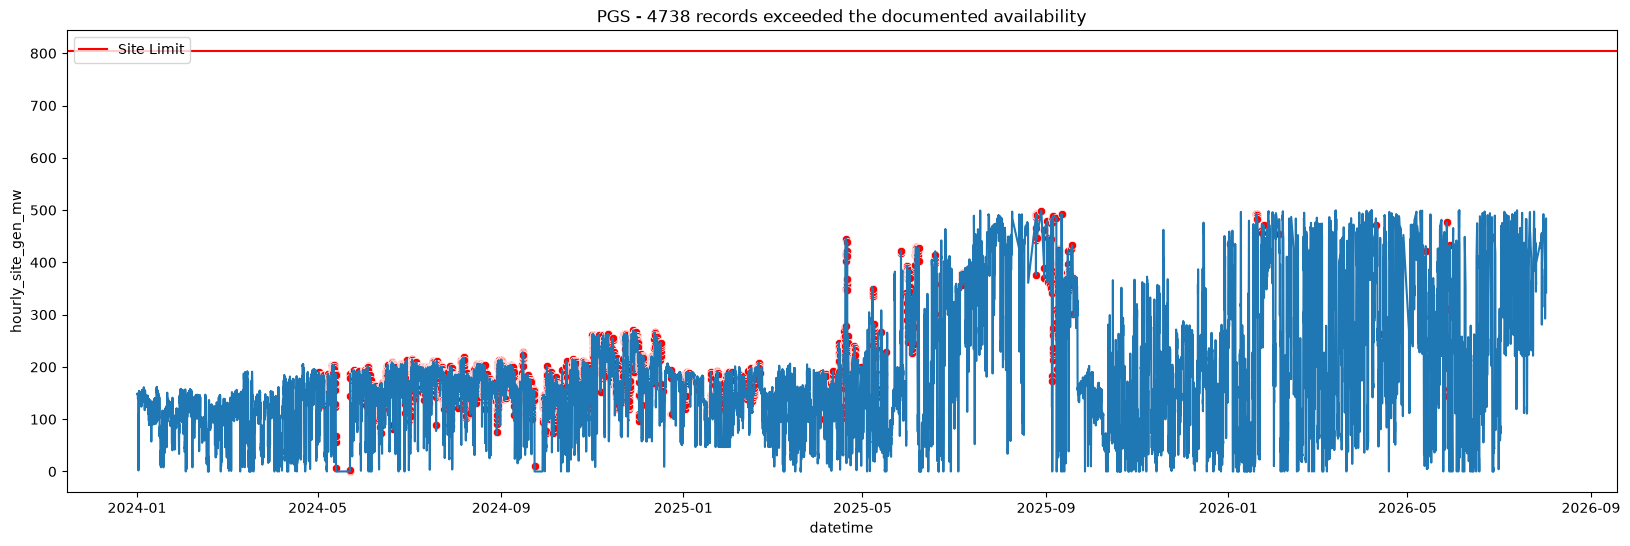

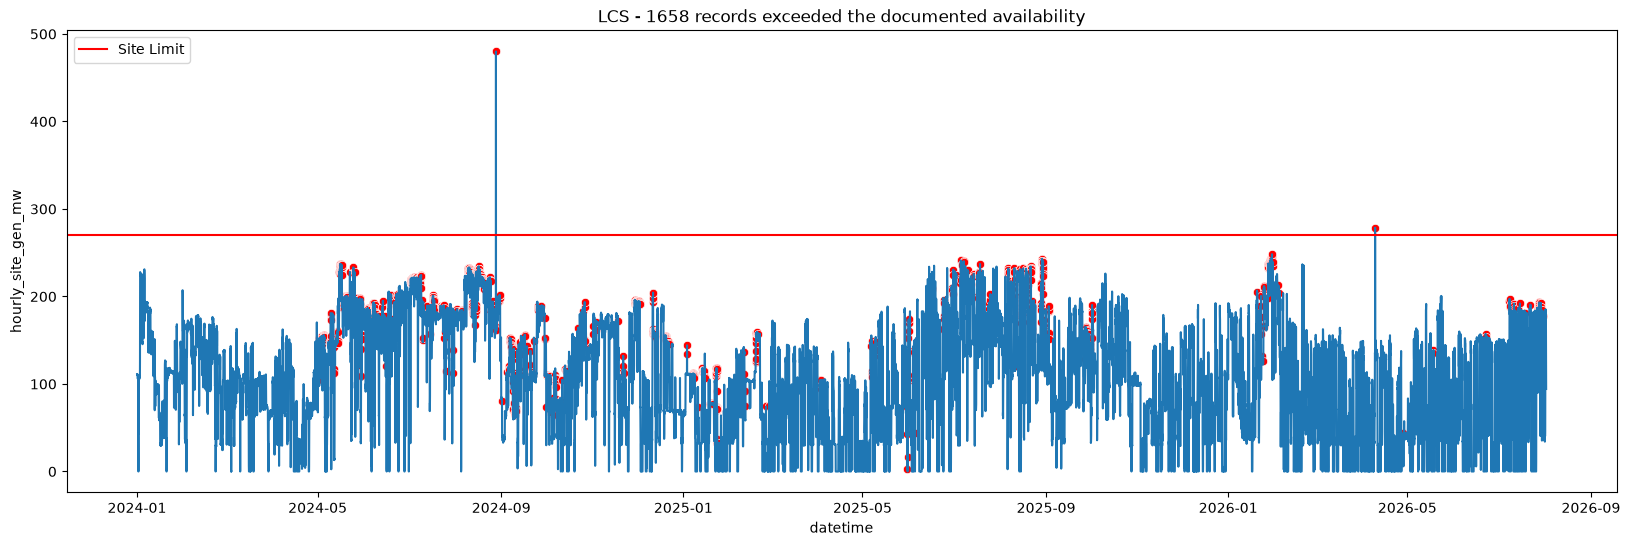

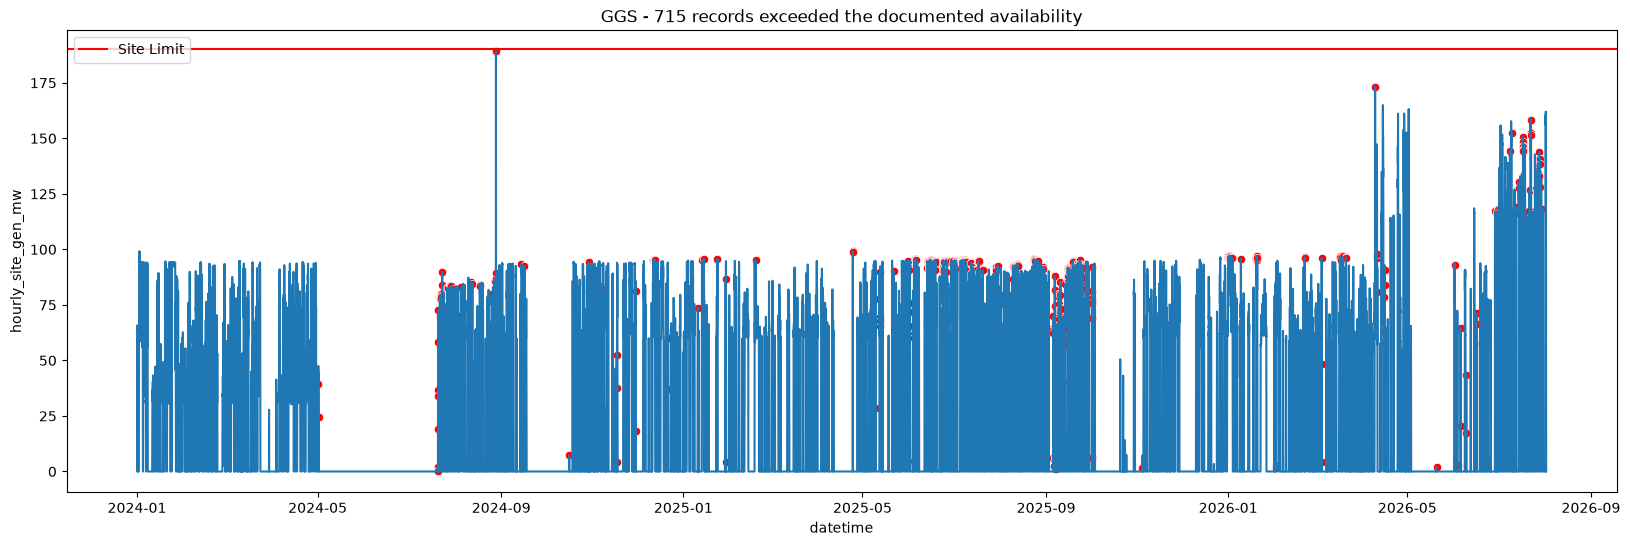

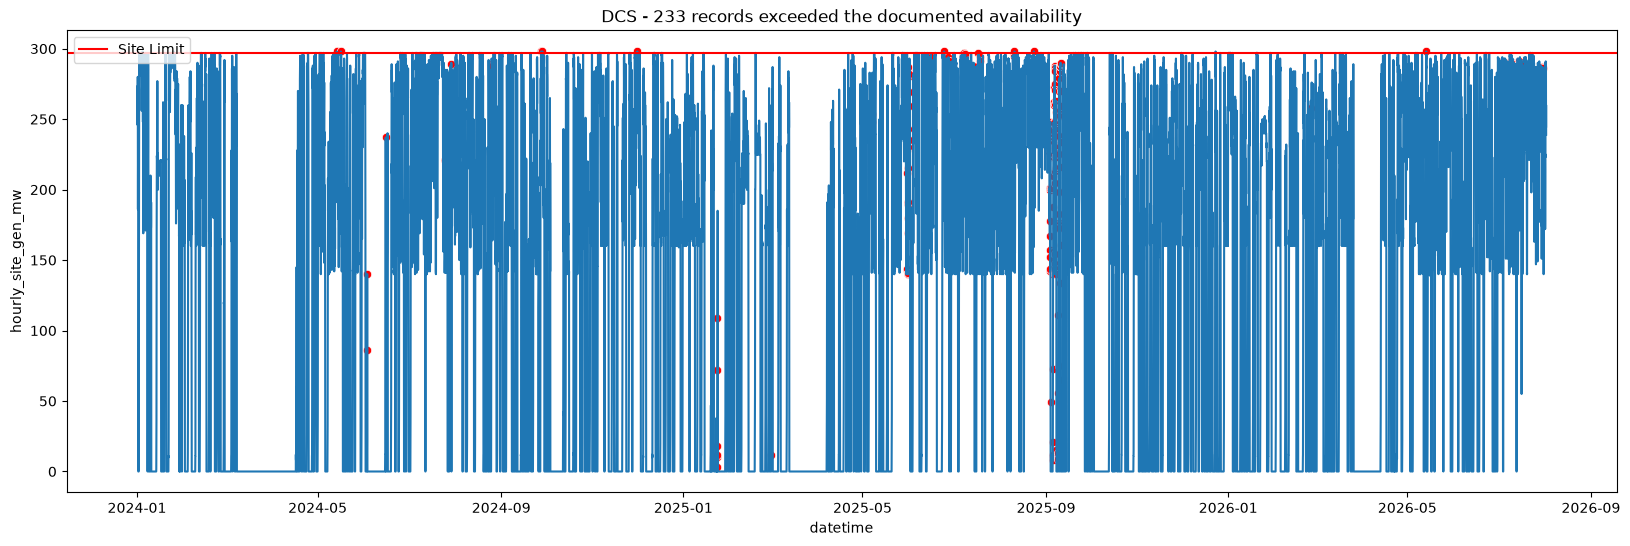

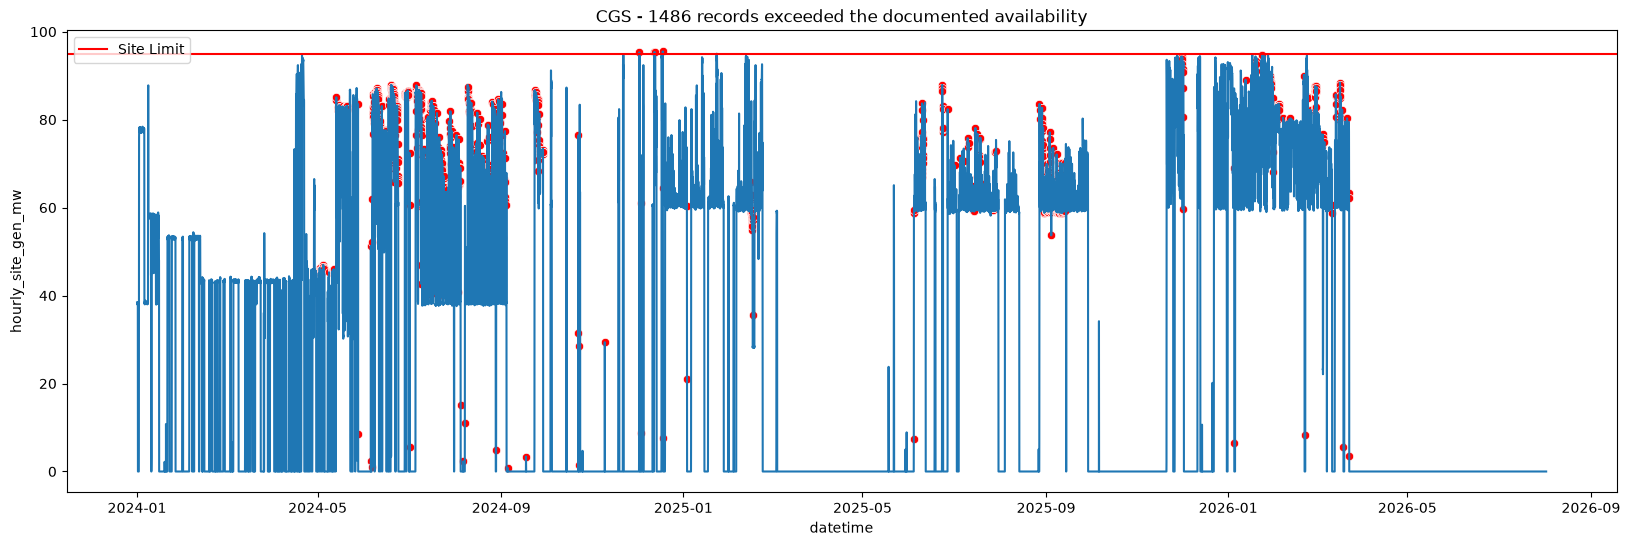

In [213]:
#There are quite a few records where generation was larger than the documented availability
for site in site_generation_df['site'].unique():
    plt.figure(figsize=(20, 6))
    ax = sns.lineplot(data = site_generation_df[(site_generation_df['hourly_site_gen_mw']<500) & (site_generation_df['site']==site)], x='datetime', y='hourly_site_gen_mw')
    ax = sns.scatterplot(data = point_data[point_data['site']==site], x='datetime', y='hourly_site_gen_mw', color='red')
    points_over = point_data[point_data['site']==site]['site'].shape[0]
    ax.set_title(f'{site} - {points_over} records exceeded the documented availability')
    ax.axhline(y=SITE_GENERATION_LIMITS[site], color='red', label='Site Limit')
    plt.legend(loc='upper left')
    plt.show()

In [ ]:
# When I look at specific examples it looks like the availability data in some of the spreadsheets is potentially wrong. I'm finding that PCI has different availability hours (usually less) than what is shown in PCI
# Based on spotchecks spreadsheets tend to have 0's but PCI shows non-zero
# example: LCS on 8/29/2025 HE21. Spreadsheet has 0s for LCS4 and LCS5 but PCI has 41
# I tend to believe PCI... Do the spreadsheets need to be updated?
for site in point_data['site'].unique():
    tmp_data = point_data[point_data['site'] == site]
    tmp_max = tmp_data.shape[0]
    tmp_idx = np.random.randint(0, tmp_max, size=10)
    print(f'\nrandom points for {site}')
    print(tmp_data.iloc[tmp_idx, :])


random points for PGS
                 datetime site  hourly_site_gen_mw  availability_mw  flag
5641  2024-07-23 02:00:00  PGS               199.5            138.7  True
5861  2024-08-01 06:00:00  PGS               159.6            105.3  True
9023  2024-12-10 21:00:00  PGS               217.9            173.9  True
10577 2025-02-13 15:00:00  PGS               146.6            140.9  True
6430  2024-08-24 23:00:00  PGS               160.0            137.5  True
5090  2024-06-30 03:00:00  PGS               114.3            109.7  True
7891  2024-10-24 20:00:00  PGS               113.3             97.8  True
15453 2025-09-04 19:00:00  PGS               384.0            171.9  True
8374  2024-11-13 20:00:00  PGS               210.5            170.3  True
15639 2025-09-12 13:00:00  PGS               361.7            297.0  True

random points for LCS
                 datetime site  hourly_site_gen_mw  availability_mw  flag
52893 2025-05-07 07:00:00  LCS               114.9             81.

In [217]:
tmp_data

,datetime,site,hourly_site_gen_mw,availability_mw,flag
164991,2024-05-01 16:00:00,CGS,45.100,45.0,True
165009,2024-05-02 10:00:00,CGS,46.200,45.0,True
165010,2024-05-02 11:00:00,CGS,45.800,45.0,True
165012,2024-05-02 13:00:00,CGS,46.200,45.0,True
165013,2024-05-02 14:00:00,CGS,45.200,45.0,True
...,...,...,...,...,...
181473,2026-03-19 04:00:00,CGS,5.531,0.0,True
181532,2026-03-21 15:00:00,CGS,80.291,80.0,True
181564,2026-03-22 23:00:00,CGS,63.397,0.0,True
181565,2026-03-23 00:00:00,CGS,62.249,0.0,True
